En el presente colab se encuentran los códigos utilizados para la clasificación de imágenes mediante Redes Neuoronales Convolucionales. Los datasets analizados fueron digitos-MNIST, fashion-MNIST y CIFAR-10. Cada celta puede ejecutarse por separado.

# Digitos-MNIST
Clasificación multiclase para un subconjunto de datos. Con la variable "x" es posible modificar el número de tuplas de entrenamiento por clase. Además, con la variable "y" se varía el número de tuplas de prueba por clase

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Clases seleccionadas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Dimensiones de entrenamiento: (400, 28, 28)
Dimensiones de prueba: (1000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.7409999966621399

Matriz de confusión (Clases 0 y 2):
 [[90  0  1  0  2  6  0  0  1  0]
 [ 0 92  0  4  0  0  0  1  3  0]
 [ 0  0 85  2  2  0  1  4  6  0]
 [ 0  0  5 82  0  6  0  5  2  0]
 [ 0  0  1  0 93  0  2  4  0  0]
 [ 3  0  1  6  3 77  0 10  0  0]
 [ 4  0 13  0 11  8 63  0  1  0]
 [ 0  0  4  0  1  0  0 93  2  0]
 [ 1  0  8  3  4  8  0 10 66  0]
 [ 0  0  3  2 39  0  0 54  2  0]]

Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       100
           1       1.00      0.92      0.96       100
           2       0.70      0.85      0.77       100
           3       0.83      0.82      0.82       100
           4       0.60      0.93      0.73       100
           5       0.73      0.77      0.75       100
           6       0.95      0.63      0.76       100
           7       0.51      0.93      0.66       100
           8       0.80      0.66      0.72       100
           9       0.00      0.00

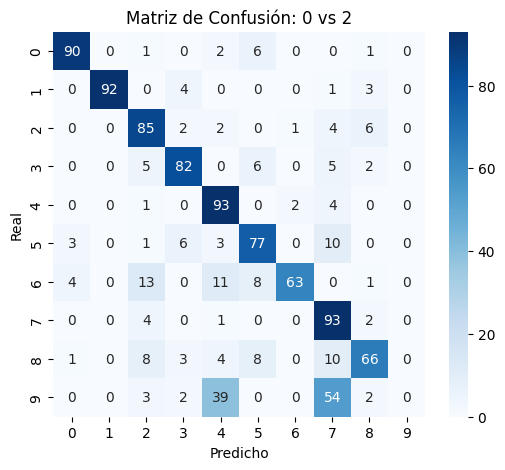

In [ ]:
# =================================================================
# Código desarrollado en colaboración con Gemini 3 Flash (Google Colab).
# Propósito: Implementación de CNN a clasificación de imágenes.
# Fecha de generación: Marzo de 2026.
# =================================================================

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# =========================
# 1. Elegir número de datos de entrenamiento y de prueba por clase
# =========================
x = 40   # <-- Número de tuplas de entrenamiento POR CLASE
y = 100    # <-- Número de tuplas de prueba POR CLASE

# =========================
# 2. Cargar datos y filtrar por dígitos u=0 y v=2
# =========================
(all_x_train, all_y_train), (all_x_test, all_y_test) = mnist.load_data()

# Definir las clases de interés
selected_digits = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

# Arrays para almacenar los datos seleccionados
x_train_selected = []
y_train_selected = []
x_test_selected = []
y_test_selected = []

for digit in selected_digits:
    # Entrenamiento
    train_indices = np.where(all_y_train == digit)[0]
    x_train_selected.extend(all_x_train[train_indices[:x]])
    y_train_selected.extend(all_y_train[train_indices[:x]])

    # Prueba
    test_indices = np.where(all_y_test == digit)[0]
    x_test_selected.extend(all_x_test[test_indices[:y]])
    y_test_selected.extend(all_y_test[test_indices[:y]])

x_train = np.array(x_train_selected)
y_train = np.array(y_train_selected)
x_test = np.array(x_test_selected)
y_test = np.array(y_test_selected)

print(f"Clases seleccionadas: {selected_digits}")
print(f"Dimensiones de entrenamiento: {x_train.shape}")
print(f"Dimensiones de prueba: {x_test.shape}")

# =========================
# 3. Normalizar
# =========================
x_train = x_train / 255.0
x_test = x_test / 255.0

# Añadir canal
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

# =========================
# 4. Modelo CNN
# =========================
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # Mantenemos 10 para compatibilidad, o podemos usar 2 con sigmoide
])

# =========================
# 5. Compilar
# =========================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# 6. Entrenar
# =========================
val_split_ratio = 0.1
model.fit(x_train, y_train, epochs=5, validation_split=val_split_ratio, verbose=0)

# =========================
# 7. Evaluación básica
# =========================
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("Accuracy:", test_acc)

# =========================
# 8. Predicciones
# =========================
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# =========================
# 9. Métricas (Filtradas para las clases 0 y 2)
# =========================
cm = confusion_matrix(y_test, y_pred, labels=selected_digits)
print("\nMatriz de confusión (Clases 0 y 2):\n", cm)

print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred, labels=selected_digits, zero_division=0))

# =========================
# 10. Mejor visualización de matriz
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=selected_digits, yticklabels=selected_digits)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión: 0 vs 2")
plt.show()

El siguiente código se enfoca en la clasificación binaria de los digitos del MNIST. Para seleccionar la dupla de digitos que desea clasificar, modifique la linea "selected digits".

Entrenando con 15 muestras por clase (Total: 30)
Epoch 1/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4074 - loss: 0.7035 - val_accuracy: 0.0000e+00 - val_loss: 0.7679
Epoch 2/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.5556 - loss: 0.6325 - val_accuracy: 0.6667 - val_loss: 0.6892
Epoch 3/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.7037 - loss: 0.5593 - val_accuracy: 1.0000 - val_loss: 0.5311
Evaluando con 100 muestras por clase (Total: 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Reporte de Clasificación:
              precision    recall  f1-score   support

           8       0.90      0.95      0.93       100
           9       0.95      0.90      0.92       100

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.92       200
weighted avg       0.93      0.93      0.92       200



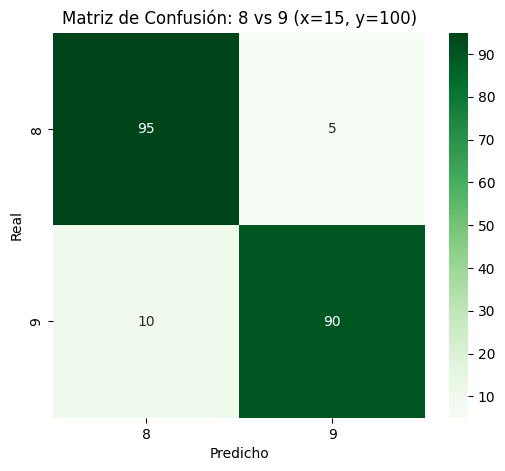

In [ ]:
# =================================================================
# Código desarrollado en colaboración con Gemini 3 Flash (Google Colab).
# Propósito: Implementación de CNN a clasificación de imágenes.
# Fecha de generación: Mayo de 2026.
# =================================================================

import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración de parámetros y carga
selected_digits = [8, 9]
x = 15  # <--- Número de tuplas de entrenamiento POR CLASE
y = 100   # <--- Número de tuplas de prueba POR CLASE

(all_x_train, all_y_train), (all_x_test, all_y_test) = datasets.mnist.load_data()

# 2. Filtrado controlado de datos para clases 0 y 2
def filter_and_limit(x_data, y_data, digits, limit_per_class):
    x_res = []
    y_res = []
    for d in digits:
        indices = np.where(y_data == d)[0][:limit_per_class]
        x_res.append(x_data[indices])
        y_res.append(y_data[indices])
    return np.concatenate(x_res), np.concatenate(y_res)

x_train_bin, y_train_raw = filter_and_limit(all_x_train, all_y_train, selected_digits, x)
x_test_bin, y_test_raw = filter_and_limit(all_x_test, all_y_test, selected_digits, y)

# Convertir etiquetas a binario (0 -> 0, 2 -> 1)
y_train_bin = np.where(y_train_raw == selected_digits[0], 0, 1)
y_test_bin = np.where(y_test_raw == selected_digits[0], 0, 1)

# 3. Preprocesamiento
x_train_bin = x_train_bin.astype('float32') / 255.0
x_test_bin = x_test_bin.astype('float32') / 255.0
x_train_bin = x_train_bin[..., np.newaxis]
x_test_bin = x_test_bin[..., np.newaxis]

# 4. Definición del modelo
binary_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

binary_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 5. Entrenamiento
print(f"Entrenando con {x} muestras por clase (Total: {len(y_train_bin)})")
binary_model.fit(x_train_bin, y_train_bin, epochs=3, validation_split=0.1, verbose=1)

# 6. Evaluación y Métricas
print(f"Evaluando con {y} muestras por clase (Total: {len(y_test_bin)})")
predictions = (binary_model.predict(x_test_bin) > 0.5).astype("int32")

cm = confusion_matrix(y_test_bin, predictions)
print("\nReporte de Clasificación:")
print(classification_report(y_test_bin, predictions, target_names=[str(d) for d in selected_digits]))

# Visualización
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=selected_digits, yticklabels=selected_digits)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title(f"Matriz de Confusión: {selected_digits[0]} vs {selected_digits[1]} (x={x}, y={y})")
plt.show()

# Fashion MNIST

Clasificación multiclase para un subconjunto de datos. Con la variable "x" es posible modificar el número de tuplas de entrenamiento por clase. Además, con la variable "y" se varía el número de tuplas de prueba por clase. En este código, además, se incluye la librería que permite calcular los gastos energéticos del modelo.

In [ ]:
!pip install codecarbon

[codecarbon WARNING @ 19:57:51] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 19:57:51] [setup] RAM Tracking...
[codecarbon INFO @ 19:57:51] [setup] CPU Tracking...
[codecarbon WARNING @ 19:57:51] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 19:57:51] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING @ 19:57:51] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 19:57:51] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 19:57:51] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 19:57:51] [setup] GPU Tracking...
[codecarbon INFO @ 19:57:51] No GPU found.
[codecarbon INFO @ 19:5

Entrenando con 1000 muestras...
Epoch 1/5


[codecarbon INFO @ 19:57:54] Energy consumed for RAM : 0.000006 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 19:57:54] Delta energy consumed for CPU with cpu_load : 0.000001 kWh, power : 1.7837324000000006 W
[codecarbon INFO @ 19:57:54] Energy consumed for All CPU : 0.000001 kWh
[codecarbon INFO @ 19:57:54] 0.000007 kWh of electricity and 0.000000 L of water were used since the beginning.


13/32 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2190 - loss: 2.2178

[codecarbon INFO @ 19:57:55] Energy consumed for RAM : 0.000007 kWh. RAM Power : 10.0 W


...

25/32 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8338 - loss: 0.4865

[codecarbon INFO @ 19:58:01] Delta energy consumed for CPU with cpu_load : 0.000001 kWh, power : 4.073078261599999 W
[codecarbon INFO @ 19:58:01] Energy consumed for All CPU : 0.000006 kWh
[codecarbon INFO @ 19:58:01] 0.000021 kWh of electricity and 0.000000 L of water were used since the beginning.


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8190 - loss: 0.5212 - val_accuracy: 0.7740 - val_loss: 0.6200


[codecarbon INFO @ 19:58:02] Energy consumed for RAM : 0.000016 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 19:58:02] Energy consumed for RAM : 0.000018 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 19:58:02] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 3.5218377115999995 W
[codecarbon INFO @ 19:58:02] Energy consumed for All CPU : 0.000006 kWh
[codecarbon INFO @ 19:58:02] 0.000024 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 19:58:02] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 0.8000576 W
[codecarbon INFO @ 19:58:02] Energy consumed for All CPU : 0.000006 kWh
[codecarbon INFO @ 19:58:02] 0.000024 kWh of electricity and 0.000000 L of water were used since the beginning.



Energía consumida: 87.3205 Joules
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


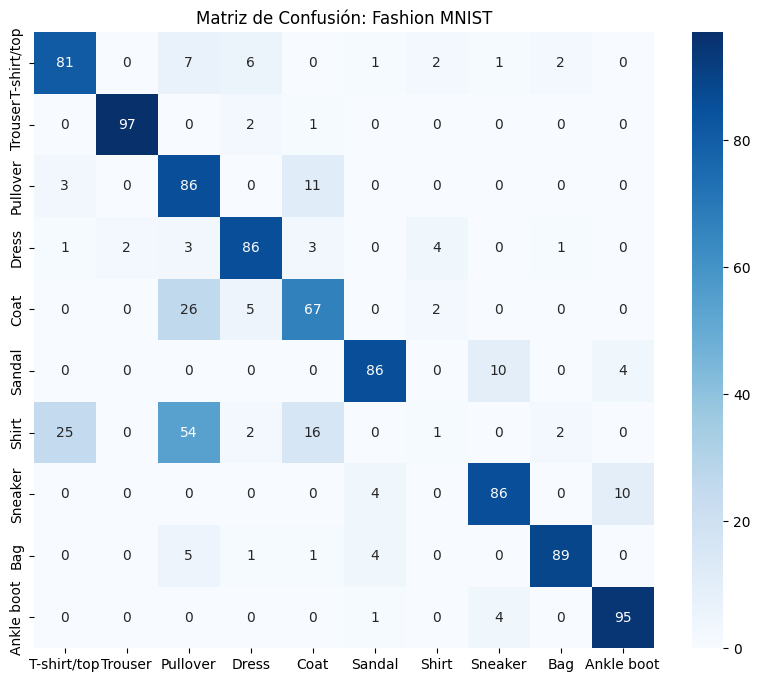


Reporte de Clasificación:
              precision    recall  f1-score   support

 T-shirt/top       0.74      0.81      0.77       100
     Trouser       0.98      0.97      0.97       100
    Pullover       0.48      0.86      0.61       100
       Dress       0.84      0.86      0.85       100
        Coat       0.68      0.67      0.67       100
      Sandal       0.90      0.86      0.88       100
       Shirt       0.11      0.01      0.02       100
     Sneaker       0.85      0.86      0.86       100
         Bag       0.95      0.89      0.92       100
  Ankle boot       0.87      0.95      0.91       100

    accuracy                           0.77      1000
   macro avg       0.74      0.77      0.75      1000
weighted avg       0.74      0.77      0.75      1000



In [ ]:
# =================================================================
# Código desarrollado en colaboración con Gemini 3 Flash (Google Colab).
# Propósito: Implementación de CNN a clasificación de imágenes.
# Fecha de generación: Abril de 2026.
# =================================================================
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from codecarbon import EmissionsTracker

# 1. Configuración de parámetros
x = 100  # Entrenamiento por clase
y = 100 # Test por clase
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 2. Carga y preprocesamiento
(all_images, all_labels), (all_test_images, all_test_labels) = datasets.fashion_mnist.load_data()

def preprocess(images):
    return images.astype('float32').reshape(-1, 28, 28, 1) / 255.0

# 3. Muestreo controlado por clase
def sample_dataset(images, labels, n_per_class):
    x_res, y_res = [], []
    for i in range(10):
        idx = np.where(labels == i)[0][:n_per_class]
        x_res.append(images[idx])
        y_res.append(labels[idx])
    return preprocess(np.concatenate(x_res)), np.concatenate(y_res)

train_images, train_labels = sample_dataset(all_images, all_labels, x)
test_images, test_labels = sample_dataset(all_test_images, all_test_labels, y)

# 4. Definición del Modelo
def build_model():
    return models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

model = build_model()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 5. Medición de Carbono y Entrenamiento
tracker = EmissionsTracker(measure_power_secs=1, save_to_file=False)
tracker.start()

print(f"Entrenando con {len(train_labels)} muestras...")
history = model.fit(train_images, train_labels, epochs=5, validation_data=(test_images, test_labels), verbose=1)

emissions = tracker.stop()
energy_joules = tracker.final_emissions_data.energy_consumed * 3600000
print(f"\nEnergía consumida: {energy_joules:.4f} Joules")

# 6. Evaluación y Matriz
y_pred = np.argmax(model.predict(test_images), axis=1)

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(test_labels, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión: Fashion MNIST')
plt.show()

print("\nReporte de Clasificación:")
print(classification_report(test_labels, y_pred, target_names=class_names))

# CIFAR-10


Clasificación multiclase para un subconjunto de datos. Recuerde que en esta situación no se analicen todas las clases del dataset, sólo las clases 0, 1, 8 y 9 (Aquellas asociadas a los medios de transporte). Con las variables "x_train_samples" y "y_test_samples" puede modificar el número de tuplas de entrenamiento y de prueba por clase respectivamente.

Entrenando con 20000 imágenes de las clases [0, 1, 8, 9]...
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 37ms/step - accuracy: 0.5873 - loss: 0.9773 - val_accuracy: 0.6988 - val_loss: 0.7662
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.7196 - loss: 0.7192 - val_accuracy: 0.7215 - val_loss: 0.6972
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 37ms/step - accuracy: 0.7727 - loss: 0.5981 - val_accuracy: 0.7810 - val_loss: 0.5768
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step - accuracy: 0.8073 - loss: 0.5182 - val_accuracy: 0.7893 - val_loss: 0.5648
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.8309 - loss: 0.4543 - val_accuracy: 0.8158 - val_loss: 0.4847
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.8485 - loss: 0.4109 - val_accuracy: 0.8183 - val_loss: 0.4783
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.8692 - loss: 0.3572 - val_accuracy: 0.8282 - val_loss: 0.4701
Epoch 8/10
625/625 ━━━━━━━━━━━

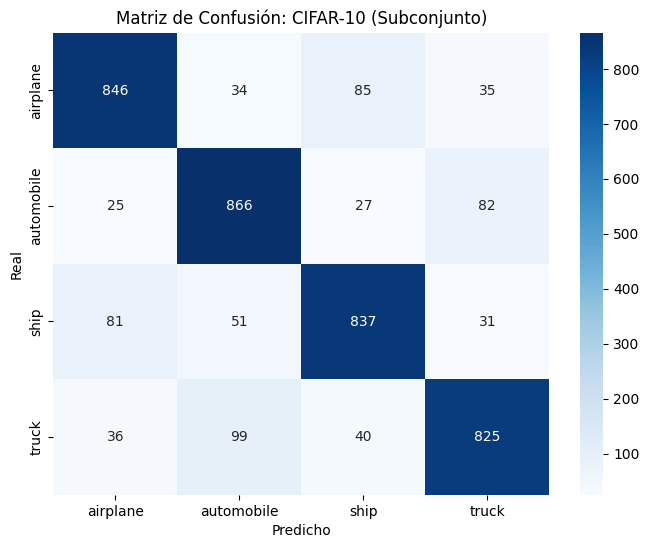

In [ ]:
# =================================================================
# Código desarrollado en colaboración con Gemini 3 Flash (Google Colab).
# Propósito: Implementación de CNN a clasificación de imágenes (CIFAR-10).
# Fecha de generación: Abril de 2026.
# =================================================================
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Configuración del número de imágenes ---
x_train_samples = 20000
y_test_samples = 4000

# Cargar los datos de CIFAR-10
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# Nombres de las clases originales de CIFAR-10
full_class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Convertir a escala de grises y normalizar
train_images_gray = tf.cast(tf.image.rgb_to_grayscale(train_images), tf.float32) / 255.0
test_images_gray = tf.cast(tf.image.rgb_to_grayscale(test_images), tf.float32) / 255.0

# Definir las clases de interés (Subconjunto)
selected_classes = [0, 1, 8, 9]

# Filtrar conjuntos
train_mask = np.isin(train_labels.flatten(), selected_classes)
test_mask = np.isin(test_labels.flatten(), selected_classes)

train_images_filtered = train_images_gray.numpy()[train_mask]
train_labels_filtered = train_labels[train_mask]
test_images_filtered = test_images_gray.numpy()[test_mask]
test_labels_filtered = test_labels[test_mask]

# Asegurar límites de submuestreo
x_train_samples = min(x_train_samples, len(train_labels_filtered))
y_test_samples = min(y_test_samples, len(test_labels_filtered))

# Submuestreo aleatorio
train_idx = np.random.choice(len(train_labels_filtered), x_train_samples, replace=False)
test_idx = np.random.choice(len(test_labels_filtered), y_test_samples, replace=False)

x_train_sub = train_images_filtered[train_idx]
y_train_sub = train_labels_filtered[train_idx]
x_test_sub = test_images_filtered[test_idx]
y_test_sub = test_labels_filtered[test_idx]

# Mapeo de etiquetas originales a consecutivas (0,1,2,3) para el reporte
label_map = {orig: i for i, orig in enumerate(selected_classes)}
inv_label_map = {i: orig for orig, i in label_map.items()}

y_train_mapped = np.array([label_map[l[0]] for l in y_train_sub])
y_test_mapped = np.array([label_map[l[0]] for l in y_test_sub])

# Arquitectura del modelo
model_subset = models.Sequential([
    layers.Input(shape=(32, 32, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(4, activation='softmax')
])

model_subset.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entrenamiento
print(f"Entrenando con {x_train_samples} imágenes de las clases {selected_classes}...")
model_subset.fit(x_train_sub, y_train_mapped, epochs=10, validation_data=(x_test_sub, y_test_mapped), verbose=1)

# Predicciones
predictions = np.argmax(model_subset.predict(x_test_sub), axis=1)

# Reporte y Visualización
target_names = [full_class_names[c] for c in selected_classes]
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test_mapped, predictions, target_names=target_names))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_mapped, predictions), annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Matriz de Confusión: CIFAR-10 (Subconjunto)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()